# Nama:Muhammad Ridwan
# NIM:4222311005
# Kelas:Malam A

In [19]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [20]:
df = pd.read_csv('WineQT.csv')

## EDA

Text(0.5, 1.0, 'Sebaran Nilai alcohol vs fixed acidity')

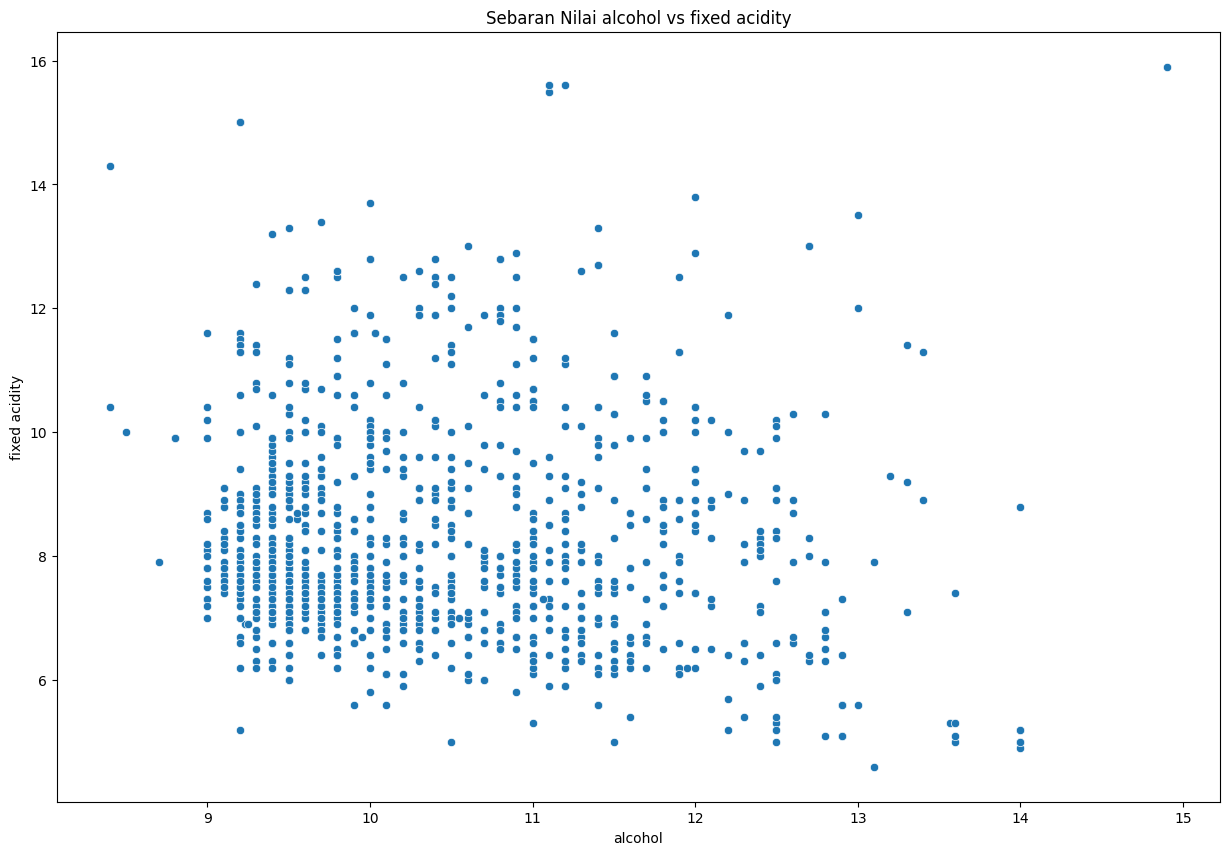

In [21]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity')
plt.title('Sebaran Nilai alcohol vs fixed acidity')

In [22]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


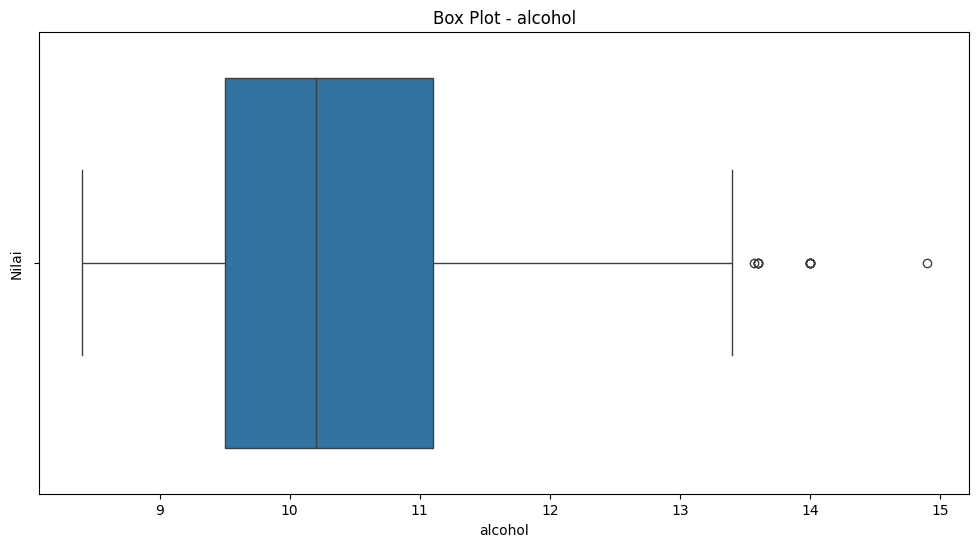

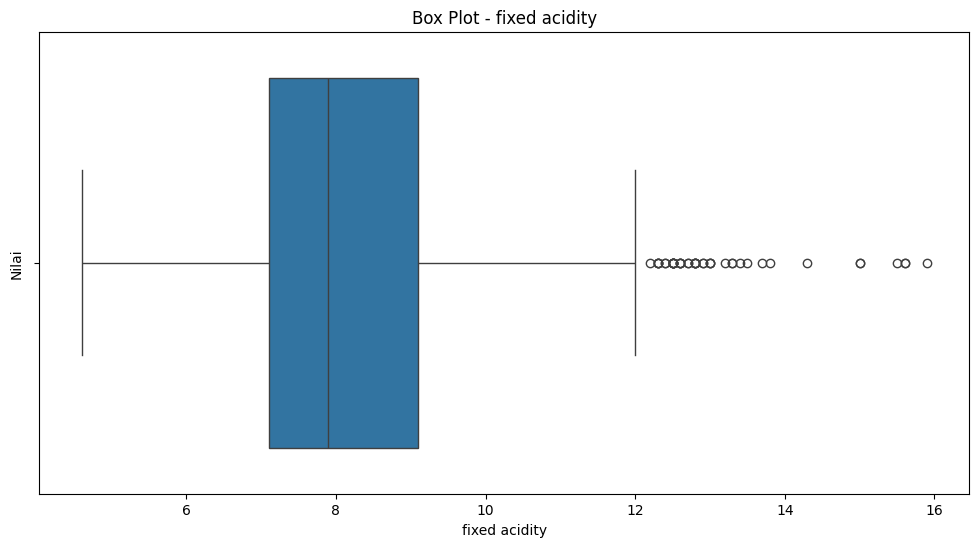

In [23]:
# Looping untuk kolom 'alcohol' dan 'fixed acidity'
columns = ['alcohol', 'fixed acidity']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

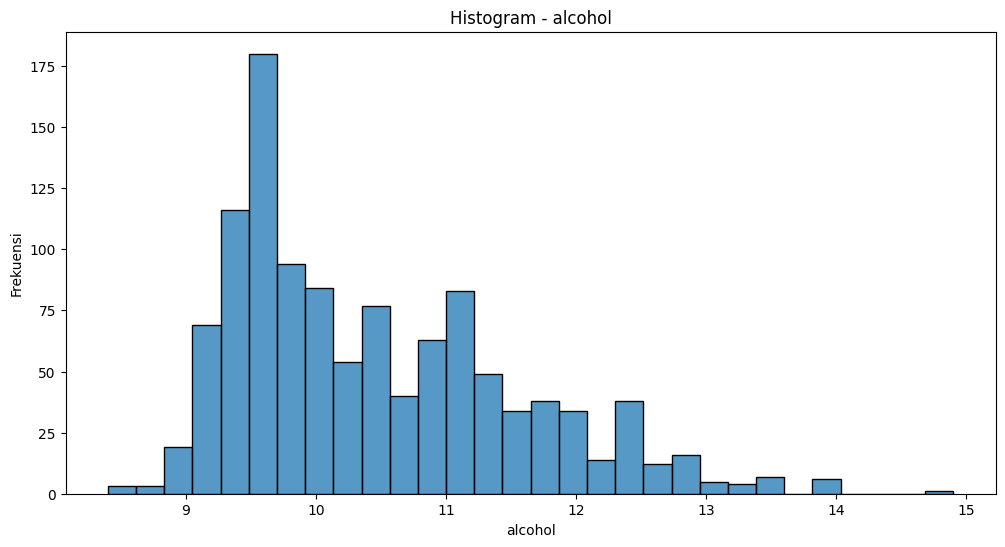

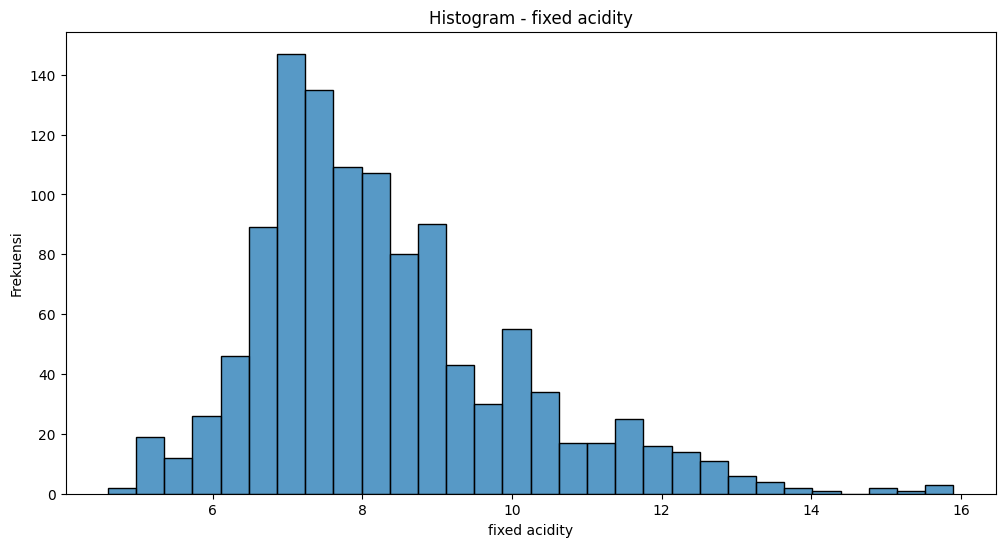

In [24]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [25]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


dari hasil running program diatas, tidak ada data yg duplikat

In [26]:
fitur_columns = ['alcohol', 'fixed acidity']
X = df[fitur_columns].values
# Removed 'deskripsi' as it's not in WineQT.csv for unsupervised learning

In [27]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,alcohol,fixed acidity
count,1.143000e+03,1.143000e+03
mean,-1.193563e-15,-3.729883e-16
std,1.000438e+00,1.000438e+00
min,-1.887834e+00,-2.124483e+00
25%,-8.709366e-01,-6.933192e-01
50%,-2.238203e-01,-2.353469e-01
75%,6.081863e-01,4.516116e-01
max,4.121103e+00,4.344377e+00


In [28]:
X_std

array([[-0.96338181, -0.52157961],
       [-0.59360107, -0.29259344],
       [-0.59360107, -0.29259344],
       ...,
       [ 0.05351522, -1.20853813],
       [ 0.70063152, -1.38027776],
       [-0.22382033, -1.38027776]])

In [29]:
df_scalling

,alcohol,fixed acidity
0,-0.963382,-0.521580
1,-0.593601,-0.292593
2,-0.593601,-0.292593
3,-0.593601,1.653789
4,-0.963382,-0.521580
...,...,...
1138,0.515741,-1.151292
1139,-0.870937,-0.865059
1140,0.053515,-1.208538
1141,0.700632,-1.380278


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

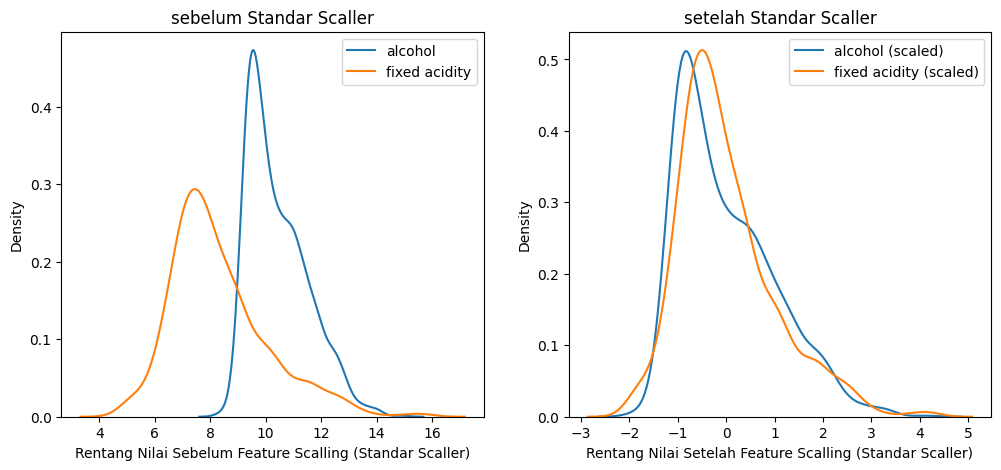

In [30]:
#cek grafik sebelum dan setelah scalling
# kita lihat distribusi dari variabel sebelum standar scaller dan setelah standar scaller

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler (Isi dibawah ini)
ax1.set_title('sebelum Standar Scaller')
sns.kdeplot(df['alcohol'], ax=ax1, label='alcohol')
sns.kdeplot(df['fixed acidity'], ax=ax1, label='fixed acidity')

# Plot distribusi setelah Standar Scaler (Isi dibawah ini)
ax2.set_title('setelah Standar Scaller')
sns.kdeplot(df_scalling['alcohol'], ax=ax2, label='alcohol (scaled)')
sns.kdeplot(df_scalling['fixed acidity'], ax=ax2, label='fixed acidity (scaled)')

# Set x-labels
ax1.set_xlabel('Rentang Nilai Sebelum Feature Scalling (Standar Scaller)')
ax2.set_xlabel('Rentang Nilai Setelah Feature Scalling (Standar Scaller)')
# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Penyamaan Skala Data: Sebelum scaling (kiri), kedua data memiliki rentang nilai yang jauh berbeda (40–100 dan 130–200). Setelah menggunakan StandardScaler (kanan), kedua data berada pada skala yang sama dengan rata-rata (mean) bernilai 0 dan rentang sekitar -3 hingga 3.

2. Bentuk Distribusi Tetap: Proses scaling berhasil mengubah rentang nilai tanpa mengubah bentuk asli distribusi data (puncak dan lekukan kurva tetap sama, hanya posisinya yang berhimpitan).

3. Penting untuk Model: Penyamaan skala ini mencegah algoritma Machine Learning memberikan bobot berlebih pada fitur yang memiliki angka lebih besar, serta membuat proses pelatihan model menjadi lebih cepat dan stabil.


## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

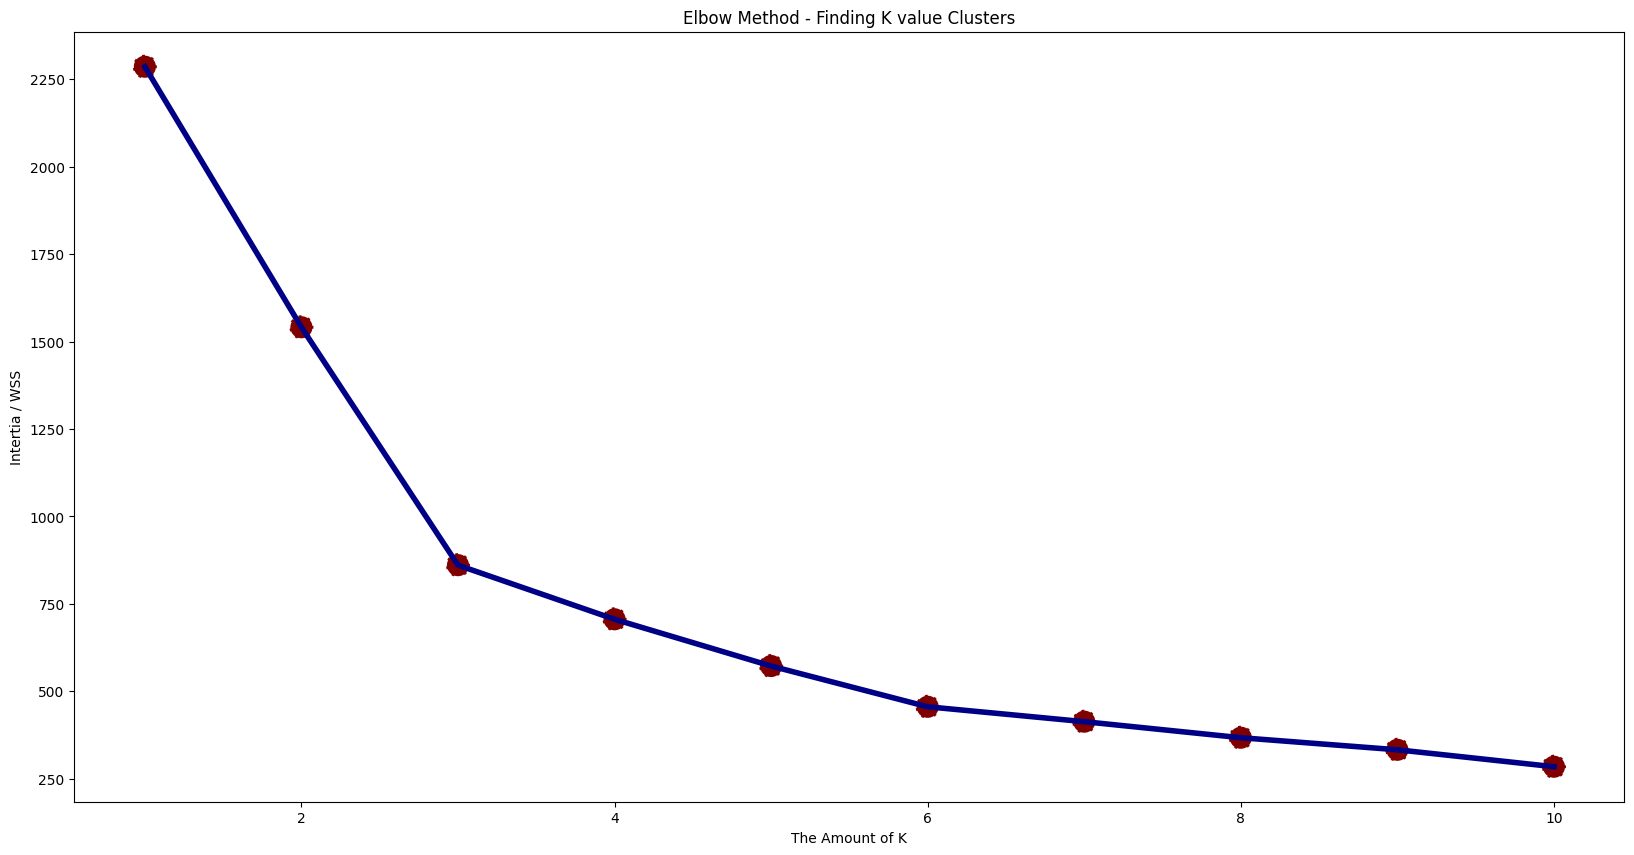

In [31]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [44]:
#Dari hasil diatas elbow nya dipilih pada angka 4,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=3, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [45]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [46]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,2,2
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,2,2


<Axes: xlabel='alcohol', ylabel='fixed acidity'>

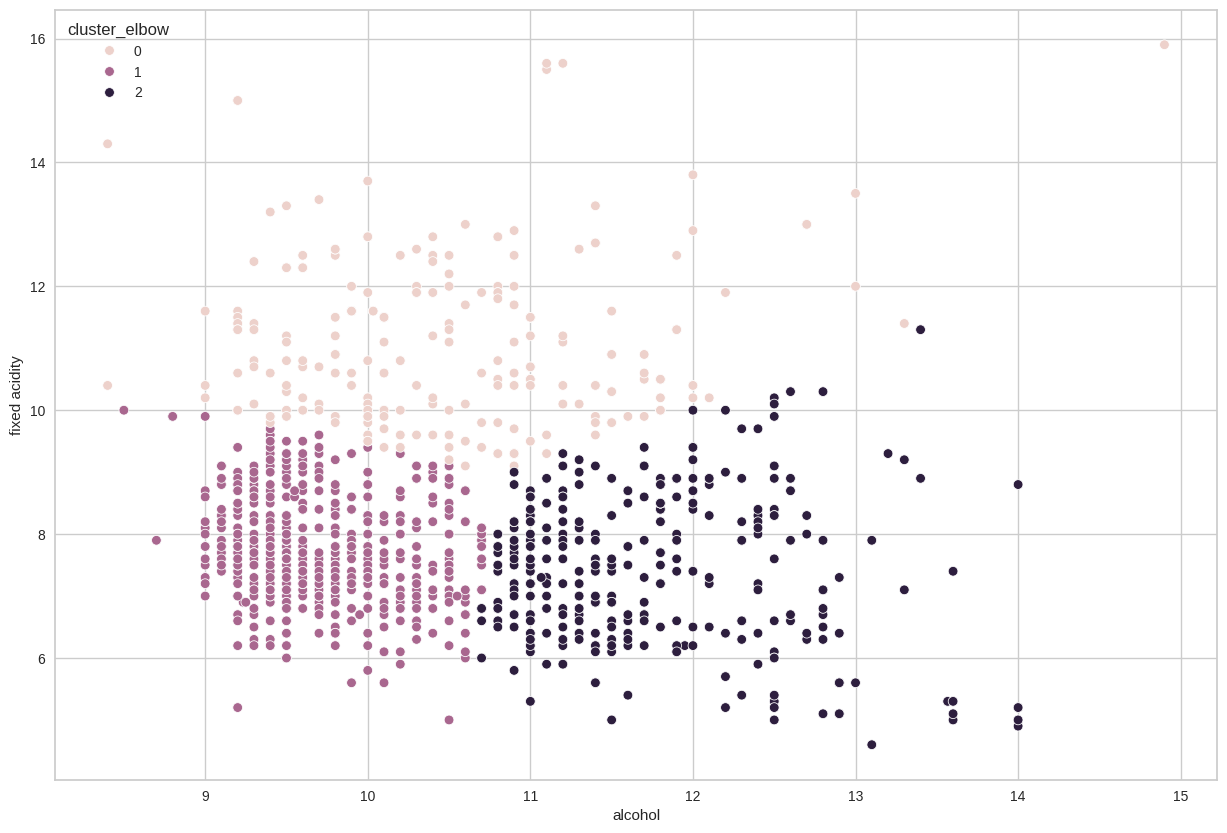

In [47]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='cluster_elbow')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='alcohol', ylabel='fixed acidity'>

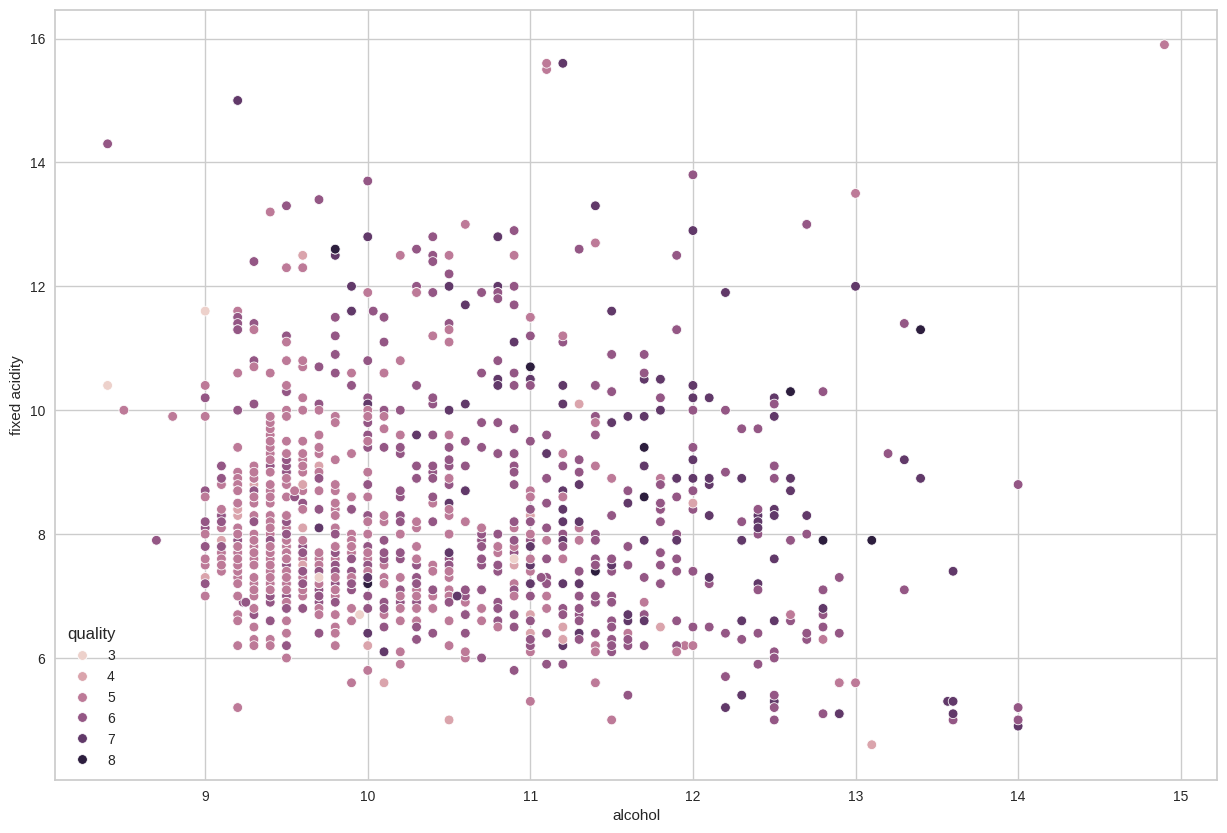

In [48]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='quality') # Using 'quality' as a proxy for 'deskripsi' for visualization

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
1. Cluster 0 -> Normal
2. Cluster 1 -> Fat
3. Cluster 2 -> Slim
4. Cluster 3 -> Obese

### 2. Via Score Plot

In [49]:
!pip install yellowbrick

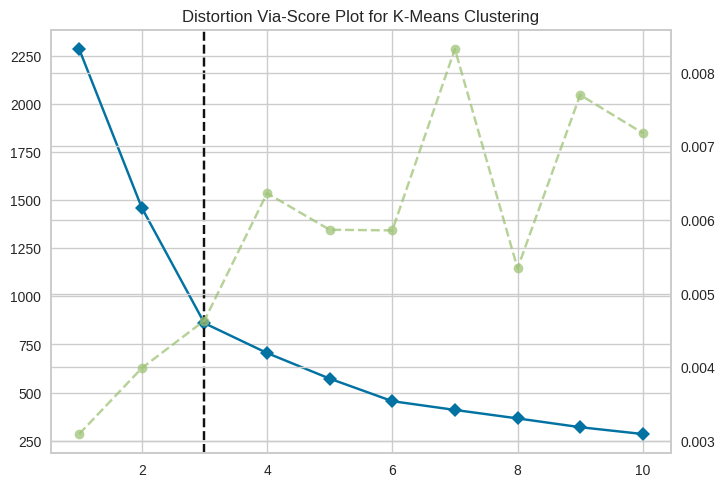

In [50]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)        # Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [51]:
# Dari hasil diatas K-nya dipilih pada angka 3,
# karena titik distorsinya bertemu pada nilai 3 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [52]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [53]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,0,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,2,2
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,1,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,2,2


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

<Axes: xlabel='alcohol', ylabel='fixed acidity'>

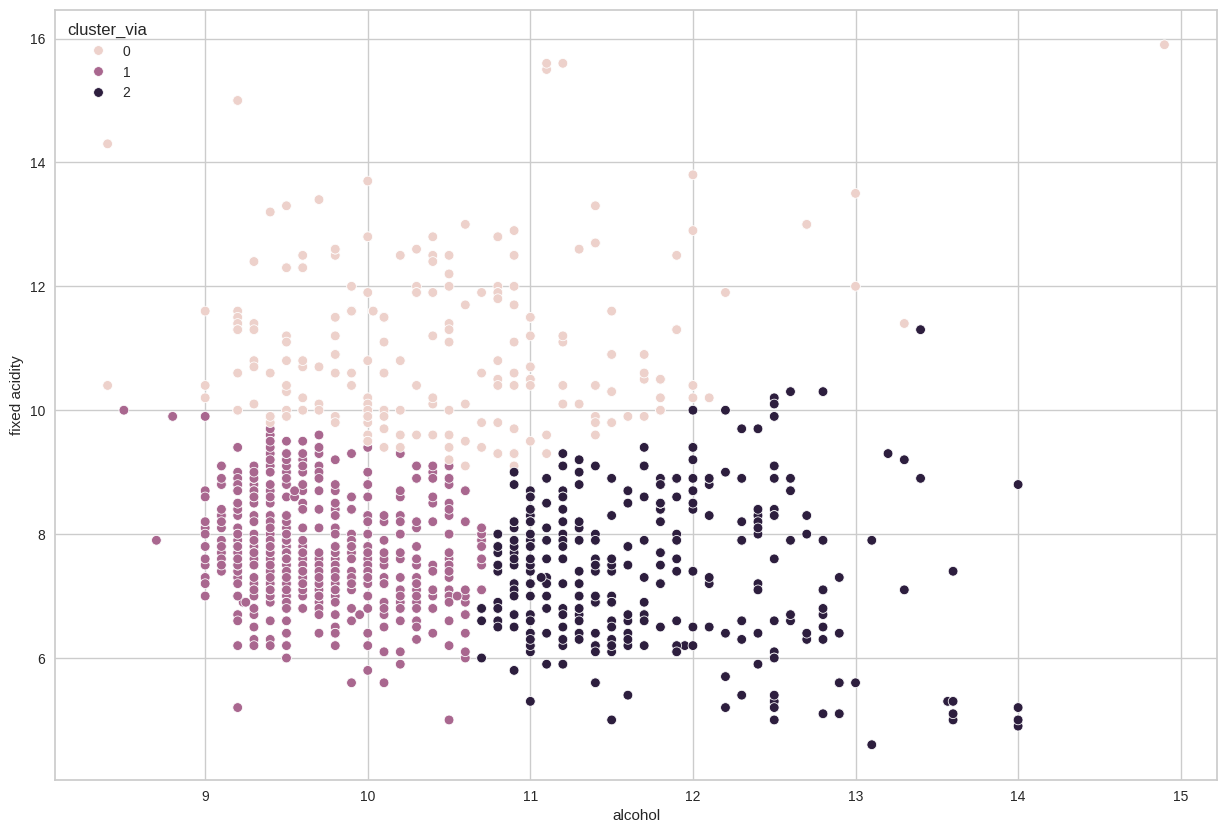

In [42]:
#Lakukan evaluasi setelah dilakukan K-Means
#Bandingkan hasil cluster dengan distribusi data asli

fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='cluster_via')

### Bandingkan dengan label anotator

<Axes: xlabel='alcohol', ylabel='fixed acidity'>

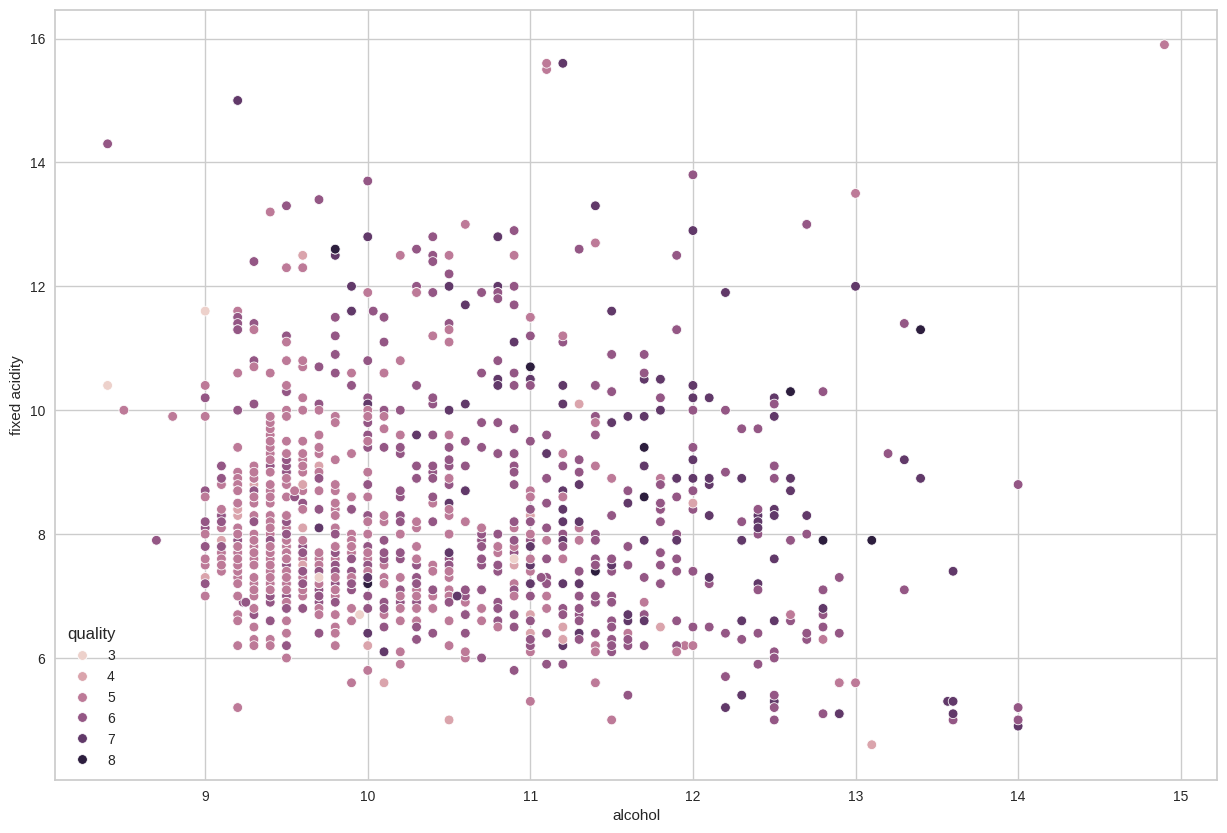

In [54]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='quality') # Using 'quality' as a proxy for 'deskripsi' for visualization

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1.   Metode Via-Score Plot menyarankan 3 cluster, yang kurang akurat dibandingkan 4 cluster dari Elbow Method jika dibandingkan dengan 4 kategori label deskripsi (anotator).
2.   Hasil Via-Score Plot cenderung menggabungkan beberapa kategori asli, sehingga kurang merepresentasikan distribusi data sebenarnya.

### Thank you :)